# Herramientas de Computación para el Análisis de Datos
## Examen 

## Nombre, Apellidos:

Jose E Rodriguez Rios

1. Explica la(s) diferencia(s) entre el coeficiente de determinación y correlación.[15 pts]

Correlacion:

se basa en cuan relacionado son  dos variables por midiendo la fuerza de su asociacion entre las dos variables, 
Puede ser un valor entre 1 a -1

 si es 1 es un correlacion positivo perfecto entre los dos variables
 si es -1 correlacion negativo perfecto
 y si es 0 ni hay correlacion
 
coeficiente de determinacion:

indica cuanta de la variacion en una variable puede ser predecida a partir de la otra variable
tiene un valor entre 0 y 1

0 explica los variables son aleatorias
y 1 explica que se puede predictar los variaciones de un variable a partir de la otra

2. Sube el archivo de data B que acompaña esta libreta. El mismo contiene grupos de notas, correspondientes a distintos semestres. Es decir, las primeras filas corresponden al semestre 1, luego cuando comienza otro encabezado comienza el grupo de notas del segundo semestre.
    1. Clasifica las notas de acuerdo a la curva estandar (A: 90-100, B:80-89, etc). Las notas deben permanecer separadas por semestre. [12 pts]
    1. Despliega el data frame que acabas de crear.[6 pts]
    1. Organiza y despliega la información de manera que quede agrupada por notas (todas las Aes en una fila, tobas las Bs en otra, etc) y cada fila de notas contiene el total de las mismas. Debes obtener 5 filas y 1 columna. [12 pts]
    1. Organiza y despliega la información de manera que quede agrupada por semestres: 5 filas (una por cada letra de nota) y dos columnas (una por cada semestre con el total correspondiente de cada nota). [12 pts]
    1. Determina si hay diferencia estadísticamente significativa entre las medias de las notas de cada semestre.[12 pts]
    1. Usa dos representaciones distintas para la data de manera que ilustren una comparación de las cantidades de las mismas notas (letras) de cada semestre. Es decir, se puede comparar las cantidades de As del primer semestre con las del segundo; lo mismo con cada letra.[16 pts]

    1. Clasifica las notas de acuerdo a la curva estandar (A: 90-100, B:80-89, etc). Las notas deben permanecer separadas por semestre. [12 pts]


In [1145]:
import numpy as np
import pandas as pd

In [1146]:
df = pd.read_csv('data_B.csv')


    2. Despliega el data frame que acabas de crear.[6 pts]


In [1147]:
df

,# Semestre 1
0,100
1,90
2,96
3,98
4,97
5,87
6,80
7,89
8,70
9,70


3. Organiza y despliega la información de manera que quede agrupada por notas (todas las Aes en una fila, tobas las Bs en otra, etc) y cada fila de notas contiene el total de las mismas. Debes obtener 5 filas y 1 columna. [12 pts]

In [1148]:
df["semester2"]=df[32:]

In [1149]:
df["semester2"] = df["semester2"].shift(-33)

In [1150]:
df["semester2"]

0     100
1      90
2      98
3      87
4      80
5      83
6      85
7      89
8      70
9      71
10     72
11     76
12     78
13     75
14     74
15     73
16     60
17     66
18     68
19     65
20     60
21     45
22     40
23     56
24     50
25    NaN
26    NaN
27    NaN
28    NaN
29    NaN
30    NaN
31    NaN
32    NaN
33    NaN
34    NaN
35    NaN
36    NaN
37    NaN
38    NaN
39    NaN
40    NaN
41    NaN
42    NaN
43    NaN
44    NaN
45    NaN
46    NaN
47    NaN
48    NaN
49    NaN
50    NaN
51    NaN
52    NaN
53    NaN
54    NaN
55    NaN
56    NaN
57    NaN
Name: semester2, dtype: object

In [1151]:
df

,# Semestre 1,semester2
0,100,100
1,90,90
2,96,98
3,98,87
4,97,80
5,87,83
6,80,85
7,89,89
8,70,70
9,70,71


In [1152]:
df=df[0:32]

In [1153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   # Semestre 1  32 non-null     object
 1   semester2     25 non-null     object
dtypes: object(2)
memory usage: 640.0+ bytes


In [1154]:
def grado(nota):
    if nota >= 90:
        return 'A'
    elif nota >= 80:
        return 'B'
    elif nota >= 70:
        return 'C'
    elif nota >= 60:
        return 'D'
    elif nota >= 0:
        return 'F'
    else:
        return 'NaN'


In [1155]:
df = df.astype(float)
df2=df.copy()

In [1156]:
df

,# Semestre 1,semester2
0,100.0,100.0
1,90.0,90.0
2,96.0,98.0
3,98.0,87.0
4,97.0,80.0
5,87.0,83.0
6,80.0,85.0
7,89.0,89.0
8,70.0,70.0
9,70.0,71.0


In [1157]:
df2['# Semestre 1'] = df2['# Semestre 1'].apply(grado)

In [1158]:
df2['semester2']=df2['semester2'].apply(grado)

In [1159]:
df2

,# Semestre 1,semester2
0,A,A
1,A,A
2,A,A
3,A,B
4,A,B
5,B,B
6,B,B
7,B,B
8,C,C
9,C,C


In [1160]:
df_melt = df2.melt()
df_melt

,variable,value
0,# Semestre 1,A
1,# Semestre 1,A
2,# Semestre 1,A
3,# Semestre 1,A
4,# Semestre 1,A
...,...,...
59,semester2,NaN
60,semester2,NaN
61,semester2,NaN
62,semester2,NaN


In [1161]:

grado_counts = df_melt['value'].value_counts().reset_index()

grado_counts.columns = ['Grade', 'Count']
grado_counts=grade_counts[:5]

grado_counts.sort_values(by=['Grade'], inplace=True)



In [1162]:
grado_counts

,Grade,Count
3,A,8
4,B,8
0,C,20
2,D,10
1,F,11


4. Organiza y despliega la información de manera que quede agrupada por semestres: 5 filas (una por cada letra de nota) y dos columnas (una por cada semestre con el total correspondiente de cada nota). [12 pts]

In [1163]:
semester_grado_counts = df_melt.groupby(['variable', 'value']).size().unstack(level=0, fill_value=0)
semester_grado_counts=semester_grado_counts[:5]
print(semester_grado_counts)


variable  # Semestre 1  semester2
value                            
A                    5          3
B                    3          5
C                   12          8
D                    5          5
F                    7          4


    5. Determina si hay diferencia estadísticamente significativa entre las medias de las notas de cada semestre.[12 pts]

In [1164]:
from scipy import stats

In [1165]:

semester1_grado = df['# Semestre 1']
semester1_grado

0     100.0
1      90.0
2      96.0
3      98.0
4      97.0
5      87.0
6      80.0
7      89.0
8      70.0
9      70.0
10     71.0
11     72.0
12     75.0
13     76.0
14     78.0
15     79.0
16     76.0
17     75.0
18     74.0
19     73.0
20     60.0
21     66.0
22     68.0
23     65.0
24     60.0
25     45.0
26     40.0
27     56.0
28     51.0
29     58.0
30     33.0
31     50.0
Name: # Semestre 1, dtype: float64

In [1166]:
semester2_grado = df['semester2']
semester2_grado=semester2_grado[:25]
semester2_grado

0     100.0
1      90.0
2      98.0
3      87.0
4      80.0
5      83.0
6      85.0
7      89.0
8      70.0
9      71.0
10     72.0
11     76.0
12     78.0
13     75.0
14     74.0
15     73.0
16     60.0
17     66.0
18     68.0
19     65.0
20     60.0
21     45.0
22     40.0
23     56.0
24     50.0
Name: semester2, dtype: float64

In [1167]:
np.mean(semester2_grado)

72.44

In [1168]:
np.mean(semester1_grado)

71.1875

In [1169]:
t_statistic, p_value = stats.ttest_ind(semester1_grado, semester2_grado)

In [1170]:
print('T-statistic:', t_statistic)
print('P-value:' ,p_value)


T-statistic: -0.2906885105335554
P-value: 0.7723828882594088


T-statistic siendo -0.29 significa que el mean de  semester1  es menor que el del semstre 2
P-value siendo mayor que 0.05 significa no hay  mucho diferencia  en la mean de los dos semetres

    6. Usa dos representaciones distintas para la data de manera que ilustren una comparación de las cantidades de las mismas notas (letras) de cada semestre. Es decir, se puede comparar las cantidades de As del primer semestre con las del segundo; lo mismo con cada letra.[16 pts]

In [1171]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Count')

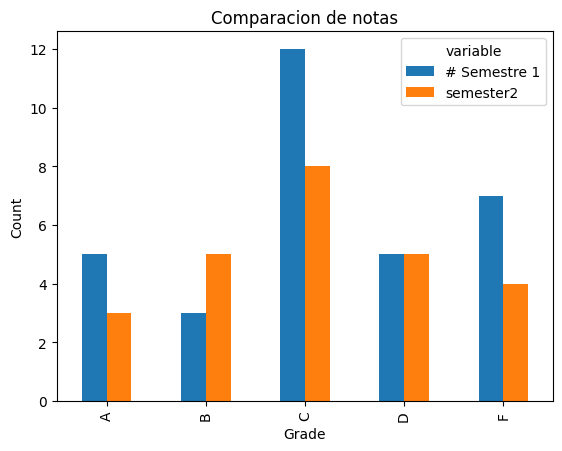

In [1172]:
semester_grado_counts.plot(kind='bar')
plt.title('Comparacion de notas')
plt.xlabel('Grade')
plt.ylabel('Count')

Text(0.5, 1.0, 'Distribucion de notas - Semester 1')

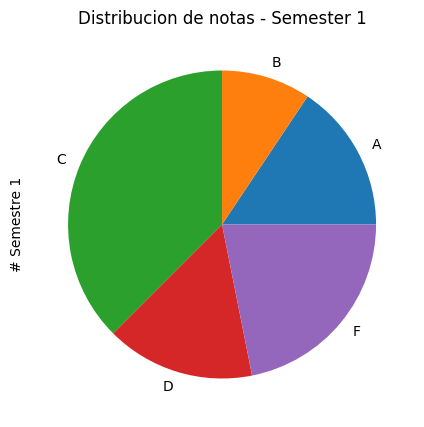

In [1173]:
semester_grado_counts['# Semestre 1'].plot(kind='pie', figsize=(5, 5))
plt.title('Distribucion de notas - Semester 1')


Text(0.5, 1.0, 'Distribucion de notas - Semester 2')

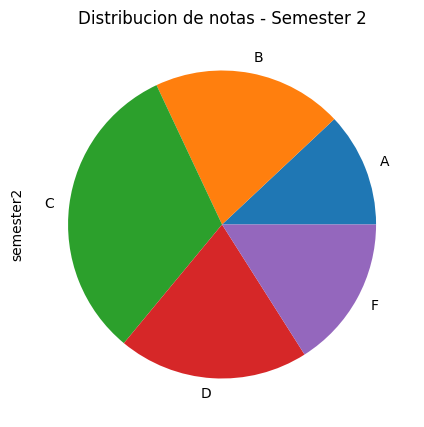

In [1174]:
semester_grado_counts['semester2'].plot(kind='pie', figsize=(5, 5))
plt.title('Distribucion de notas - Semester 2')

3. Explica cuál es el proposito de la línea de código #7, __x= df['a'].values.reshape(-1,1)__, en el segemento de código siguiente: [15 pts]

In [1175]:
import sklearn.linear_model as skl

a= np.array([100, 95, 90, 102, 94])
b = np.array([37.78, 35.0, 32.22, 38.89,34.44])
df = pd.DataFrame({'a': a, 'b': b})
model = skl.LinearRegression()
x= df['a'].values.reshape(-1,1)
model.fit(x, df['b'])
y_pred = model.predict(x)

In [1176]:
x

array([[100],
       [ 95],
       [ 90],
       [102],
       [ 94]])

In [1177]:
print(x.ndim) #numero de dimensiones

2


In [1178]:
a

array([100,  95,  90, 102,  94])

Contestacion:
coge los valores del columna a y lo convierte en un arreglo de dos dimesiones con una sola columna para que se pueda correr en el sklearn linearl regression modelo